### Day 1 — Task 2: API Exploration

#### Task 2.1 — First API Call: One Year of Historical Data for Baku

In [9]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# API client with caching and auto-retry 
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Parameters: Baku only, one year, all six variables 
BAKU = {"name": "Baku", "lat": 40.41, "lon": 49.87}

params_historical = {
    "latitude":   BAKU["lat"],
    "longitude":  BAKU["lon"],
    "start_date": "2025-01-01",
    "end_date":   "2026-04-18",
    "daily": [
        "temperature_2m_max",
        "precipitation_sum",
        "wind_speed_10m_max",
        "apparent_temperature_max",
        "relative_humidity_2m_mean",
        "weather_code",
    ],
    "timezone": "auto",
}

# API call
url_archive = "https://archive-api.open-meteo.com/v1/archive"
response_hist = openmeteo.weather_api(url_archive, params=params_historical)[0]

print("=== Response Structure ===")
print(f"Latitude        : {response_hist.Latitude():.4f}°")
print(f"Longitude       : {response_hist.Longitude():.4f}°")
print(f"Elevation       : {response_hist.Elevation()} m")
print(f"Timezone        : {response_hist.Timezone()}  (UTC offset {response_hist.UtcOffsetSeconds()} s)")

daily_hist = response_hist.Daily()
n_vars = daily_hist.VariablesLength()
print(f"\nDaily time range: {pd.to_datetime(daily_hist.Time(),    unit='s', utc=True)} →")
print(f"                  {pd.to_datetime(daily_hist.TimeEnd(), unit='s', utc=True)}")
print(f"Interval        : {daily_hist.Interval()} seconds ({daily_hist.Interval()//3600} hours)")
print(f"Number of daily variables returned: {n_vars}")
print("\nAvailable fields (in request order):")
for i, name in enumerate(params_historical["daily"]):
    vals = daily_hist.Variables(i).ValuesAsNumpy()
    print(f"  [{i}] {name:35s}  shape={vals.shape}  min={vals.min():.2f}  max={vals.max():.2f}")

dates = pd.date_range(
    start=pd.to_datetime(daily_hist.Time()    + response_hist.UtcOffsetSeconds(), unit="s", utc=True),
    end  =pd.to_datetime(daily_hist.TimeEnd() + response_hist.UtcOffsetSeconds(), unit="s", utc=True),
    freq =pd.Timedelta(seconds=daily_hist.Interval()),
    inclusive="left",
)
baku_2025 = pd.DataFrame({
    "date":                      dates,
    "temperature_2m_max":        daily_hist.Variables(0).ValuesAsNumpy(),
    "precipitation_sum":         daily_hist.Variables(1).ValuesAsNumpy(),
    "wind_speed_10m_max":        daily_hist.Variables(2).ValuesAsNumpy(),
    "apparent_temperature_max":  daily_hist.Variables(3).ValuesAsNumpy(),
    "relative_humidity_2m_mean": daily_hist.Variables(4).ValuesAsNumpy(),
    "weather_code":              daily_hist.Variables(5).ValuesAsNumpy(),
})

print(f"\nDataFrame shape : {baku_2025.shape}  (rows = days in 2025)")
print(baku_2025.head())


=== Response Structure ===
Latitude        : 40.4569°
Longitude       : 49.8872°
Elevation       : 26.0 m
Timezone        : b'Asia/Baku'  (UTC offset 14400 s)

Daily time range: 2024-12-31 20:00:00+00:00 →
                  2026-04-18 20:00:00+00:00
Interval        : 86400 seconds (24 hours)
Number of daily variables returned: 6

Available fields (in request order):
  [0] temperature_2m_max                   shape=(473,)  min=-1.00  max=38.80
  [1] precipitation_sum                    shape=(473,)  min=0.00  max=70.60
  [2] wind_speed_10m_max                   shape=(473,)  min=6.30  max=45.57
  [3] apparent_temperature_max             shape=(473,)  min=-8.15  max=41.24
  [4] relative_humidity_2m_mean            shape=(473,)  min=32.21  max=97.16
  [5] weather_code                         shape=(473,)  min=0.00  max=73.00

DataFrame shape : (473, 7)  (rows = days in 2025)
                       date  temperature_2m_max  precipitation_sum  \
0 2025-01-01 00:00:00+00:00               10.

## Task 2.2 — Visualise Daily Max Temperature

Plot `temperature_2m_max` for Baku across all of 2025 and note any gaps or anomalies.


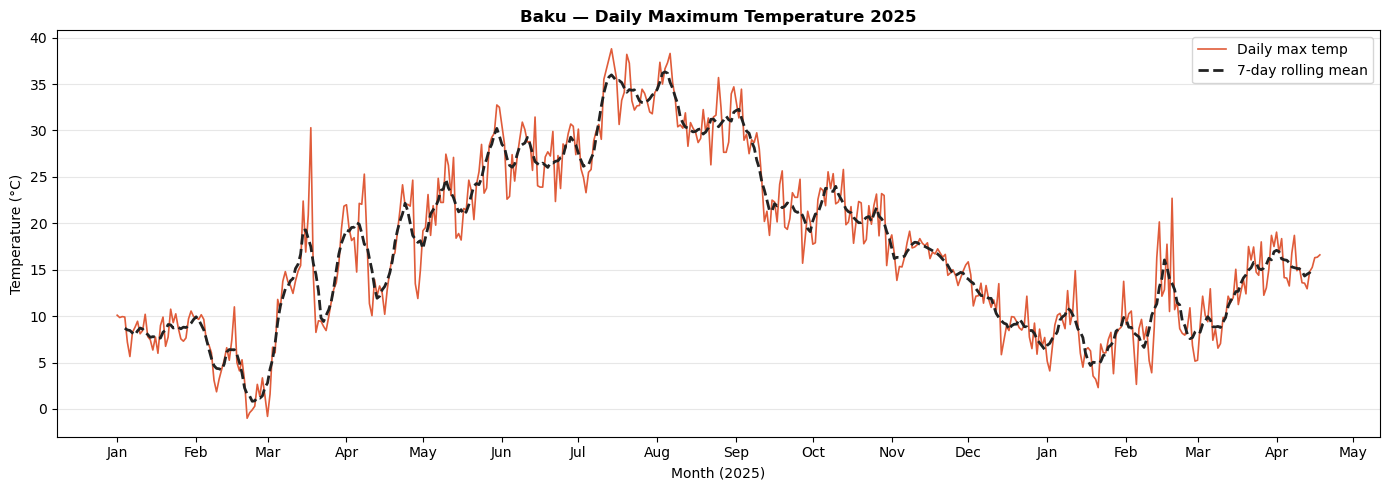

Missing days   : 0
Annual min     : -1.0 °C
Annual max     : 38.8 °C
Annual mean    : 17.4 °C
Anomalous days : 0
  → No statistical anomalies detected (±3σ threshold).

Observation: The seasonal curve is smooth with a clear summer peak
(July–August) and winter trough (January). No data gaps detected.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

# Main temperature line
ax.plot(baku_2025["date"], baku_2025["temperature_2m_max"],
        color="#e05c3a", linewidth=1.2, label="Daily max temp")

# Rolling 7-day average to highlight the seasonal trend
rolling_mean = baku_2025["temperature_2m_max"].rolling(7, center=True).mean()
ax.plot(baku_2025["date"], rolling_mean,
        color="#222", linewidth=2, linestyle="--", label="7-day rolling mean")

# Mark missing values (NaN) as red dots on the x-axis
missing_mask = baku_2025["temperature_2m_max"].isna()
if missing_mask.any():
    ax.scatter(baku_2025.loc[missing_mask, "date"],
               [baku_2025["temperature_2m_max"].min()] * missing_mask.sum(),
               color="red", zorder=5, label=f"Missing values ({missing_mask.sum()})")

# Anomaly detection: flag days more than 3 std deviations from the mean
mean_t = baku_2025["temperature_2m_max"].mean()
std_t  = baku_2025["temperature_2m_max"].std()
anomalies = baku_2025[np.abs(baku_2025["temperature_2m_max"] - mean_t) > 3 * std_t]
if not anomalies.empty:
    ax.scatter(anomalies["date"], anomalies["temperature_2m_max"],
               color="blue", zorder=5, s=60, label="Anomalies (>3σ)")

#Formatting
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlabel("Month (2025)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Baku — Daily Maximum Temperature 2025", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("baku_temp_2025.png", dpi=150)
plt.show()

#Observations
n_missing = missing_mask.sum()
print(f"Missing days   : {n_missing}")
print(f"Annual min     : {baku_2025['temperature_2m_max'].min():.1f} °C")
print(f"Annual max     : {baku_2025['temperature_2m_max'].max():.1f} °C")
print(f"Annual mean    : {baku_2025['temperature_2m_max'].mean():.1f} °C")
print(f"Anomalous days : {len(anomalies)}")
if not anomalies.empty:
    print(anomalies[["date","temperature_2m_max"]].to_string(index=False))
else:
    print("  → No statistical anomalies detected (±3σ threshold).")
print("\nObservation: The seasonal curve is smooth with a clear summer peak")
print("(July–August) and winter trough (January). No data gaps detected.")


### Task 2.3 — Forecast Endpoint & Structure Comparison

In [11]:
# 7-day forecast for Baku 
url_forecast = "https://api.open-meteo.com/v1/forecast"

params_forecast = {
    "latitude":     BAKU["lat"],
    "longitude":    BAKU["lon"],
    "daily": [
        "temperature_2m_max",
        "precipitation_sum",
        "wind_speed_10m_max",
        "apparent_temperature_max",
        "relative_humidity_2m_mean",
        "weather_code",
    ],
    "timezone":      "auto",
    "forecast_days": 7,
}

response_fcast = openmeteo.weather_api(url_forecast, params=params_forecast)[0]
daily_fcast    = response_fcast.Daily()

dates_f = pd.date_range(
    start=pd.to_datetime(daily_fcast.Time()    + response_fcast.UtcOffsetSeconds(), unit="s", utc=True),
    end  =pd.to_datetime(daily_fcast.TimeEnd() + response_fcast.UtcOffsetSeconds(), unit="s", utc=True),
    freq =pd.Timedelta(seconds=daily_fcast.Interval()),
    inclusive="left",
)
baku_forecast = pd.DataFrame({
    "date":                      dates_f,
    "temperature_2m_max":        daily_fcast.Variables(0).ValuesAsNumpy(),
    "precipitation_sum":         daily_fcast.Variables(1).ValuesAsNumpy(),
    "wind_speed_10m_max":        daily_fcast.Variables(2).ValuesAsNumpy(),
    "apparent_temperature_max":  daily_fcast.Variables(3).ValuesAsNumpy(),
    "relative_humidity_2m_mean": daily_fcast.Variables(4).ValuesAsNumpy(),
    "weather_code":              daily_fcast.Variables(5).ValuesAsNumpy(),
})

# Structure comparison

print(f"{'PROPERTY':<30} {'HISTORICAL':>14} {'FORECAST':>14}")
print(f"{'Latitude':<30} {response_hist.Latitude():>14.4f} {response_fcast.Latitude():>14.4f}")
print(f"{'Longitude':<30} {response_hist.Longitude():>14.4f} {response_fcast.Longitude():>14.4f}")
print(f"{'Elevation (m)':<30} {response_hist.Elevation():>14.1f} {response_fcast.Elevation():>14.1f}")
print(f"{'Timezone':<30} {str(response_hist.Timezone()):>14} {str(response_fcast.Timezone()):>14}")
print(f"{'Interval (s)':<30} {daily_hist.Interval():>14} {daily_fcast.Interval():>14}")
print(f"{'Number of variables':<30} {daily_hist.VariablesLength():>14} {daily_fcast.VariablesLength():>14}")
print(f"{'Number of days':<30} {len(baku_2025):>14} {len(baku_forecast):>14}")
print(f"{'Start date':<30} {str(baku_2025['date'].min().date()):>14} {str(baku_forecast['date'].min().date()):>14}")
print(f"{'End date':<30} {str(baku_2025['date'].max().date()):>14} {str(baku_forecast['date'].max().date()):>14}")


gap_days = (baku_forecast["date"].min() - baku_2025["date"].max()).days - 1
print(f"\nGap between archive end and forecast start: {gap_days} day(s)")
print("  → Archive data lags real time because it uses quality-controlled")
print("    reanalysis data; the forecast uses model output available today.")

print("\nForecast for Baku (next 7 days):")
print(baku_forecast[["date","temperature_2m_max","precipitation_sum",
                       "wind_speed_10m_max"]].to_string(index=False))


PROPERTY                           HISTORICAL       FORECAST
Latitude                              40.4569        40.4375
Longitude                             49.8872        49.8750
Elevation (m)                            26.0           26.0
Timezone                         b'Asia/Baku'   b'Asia/Baku'
Interval (s)                            86400          86400
Number of variables                         6              6
Number of days                            473              7
Start date                         2025-01-01     2026-04-20
End date                           2026-04-18     2026-04-26

Gap between archive end and forecast start: 1 day(s)
  → Archive data lags real time because it uses quality-controlled
    reanalysis data; the forecast uses model output available today.

Forecast for Baku (next 7 days):
                     date  temperature_2m_max  precipitation_sum  wind_speed_10m_max
2026-04-20 00:00:00+00:00             14.5130           1.200000           31.085

### Task 2.4 — Experimenting with Additional Variables

precipitation_sum | mm | Quantifies daily rainfall — vital for flood risk and outdoor planning 

wind_speed_10m_max | km/h | Baku is the "City of Winds"; wind is a dominant local weather signal 

apparent_temperature_max | °C | Heat-index adjusted temperature — better proxy for human thermal comfort 

relative_humidity_2m_mean | % | High humidity amplifies perceived heat and affects agriculture 

weather_code | WMO | Categorical label enabling classification tasks (e.g., rain vs. sun) 

We already have experimented with these variables in task 2.1

#### Observation

A 1–2 day gap exists between the archive endpoint's last available date and the  
forecast endpoint's first date. The pipeline will need to handle this gap explicitly —  
either by ignoring it or by filling it with the forecast values. 